# ADALINE desde cero: de la formulación matemática a una arquitectura computacional

## Parcial en casa — componente práctico

En el ejercicio anterior trabajamos con el perceptrón de Rosenblatt. Allí la arquitectura funcional fue construida conjuntamente y el trabajo consistió en completar las funciones que la componían.

En este ejercicio cambia deliberadamente el nivel de autonomía:

> **usted recibe el problema, la formulación matemática, una función fundamental ya implementada, datos, experimentos y criterios de integración; la arquitectura de software debe diseñarla usted.**

No existe una única arquitectura correcta. Dos soluciones pueden ser diferentes y ambas ser válidas si:

- las responsabilidades están bien separadas;
- los contratos de entrada y salida son claros;
- la implementación reproduce correctamente el algoritmo;
- las funciones se conectan de manera coherente;
- las pruebas permiten verificar el comportamiento esperado.

El cuaderno es **autocontenido**: no necesita un PDF externo ni archivos de datos adicionales.

### Qué debe entregar dentro de este mismo notebook

1. propuesta de arquitectura funcional;
2. diagrama de conexión entre funciones;
3. derivación de la regla de actualización;
4. implementación de ADALINE con NumPy;
5. validaciones con `raise ValueError`;
6. `type hints` y docstrings;
7. pruebas diseñadas por usted;
8. entrenamiento y seguimiento de la pérdida;
9. experimentos con el `learning rate`;
10. comparación entre variables en escalas distintas y variables estandarizadas;
11. evaluación sobre train, validation y test;
12. comparación conceptual entre perceptrón y ADALINE;
13. reflexión final sobre sus decisiones de arquitectura.

### Restricciones

- El núcleo de ADALINE debe implementarse con **NumPy**.
- No utilice una implementación equivalente de `scikit-learn`, TensorFlow, PyTorch u otra biblioteca.
- No utilice clases. La solución debe permanecer en una arquitectura funcional.
- Puede crear tantas funciones auxiliares como considere necesarias.
- Debe utilizar la función `actualizar_pesos_adaline` proporcionada.
- Para que las celdas posteriores puedan ejecutar arquitecturas diferentes, deberá respetar únicamente dos **interfaces públicas**:
  - `entrenar_adaline(...)`
  - `predecir_adaline(...)`

Estas dos firmas no determinan la arquitectura interna.

### Dependencias

En el ambiente del curso deben estar disponibles:

```bash
uv add numpy pandas matplotlib
```

El ambiente virtual no debe subirse al repositorio.

# 1. ¿Qué cambia respecto al perceptrón?

Ambos modelos parten de:

\[
z_i=\mathbf w^\top \tilde{\mathbf x}_i.
\]

La diferencia está en **cómo utilizan esa cantidad para aprender**.

### Perceptrón

\[
y_i z_i\le 0
\quad\Longrightarrow\quad
\mathbf w\leftarrow\mathbf w+\eta y_i\tilde{\mathbf x}_i.
\]

La pregunta esencial es:

> ¿la observación quedó bien o mal clasificada?

### ADALINE

Durante el entrenamiento ADALINE utiliza directamente la salida lineal:

\[
a_i=z_i=\mathbf w^\top\tilde{\mathbf x}_i,
\]

y define un error continuo:

\[
e_i=y_i-a_i.
\]

Por tanto, la magnitud del error sí participa en el aprendizaje.

En este ejercicio:

\[
y_i\in\{-1,+1\}.
\]

La función signo aparecerá **solo para convertir la salida lineal en una clase durante inferencia**.

# 2. La función que queremos minimizar

Trabajaremos con:

\[
\boxed{
L(\mathbf w)=
\frac{1}{2n}
\sum_{i=1}^{n}
\left(
y_i-\mathbf w^\top\tilde{\mathbf x}_i
\right)^2
}
\]

o, matricialmente,

\[
L(\mathbf w)
=
\frac{1}{2n}
\left\|
\mathbf y-\tilde X\mathbf w
\right\|_2^2.
\]

Antes de programar, responda:

1. ¿por qué el cuadrado evita que errores positivos y negativos se cancelen?;
2. ¿qué efecto tiene sobre errores de distinta magnitud?;
3. ¿por qué el factor \(1/2\) es conveniente?;
4. ¿qué variable estamos optimizando?

**Respuesta:**

> 1. Porque si sumara los errores tal cual (sin elevar al cuadrado), uno positivo y uno negativo se anulan entre sí, lo que esconde el hecho de que el modelo se equivocó en ambos casos. Al elevar al cuadrado, no importa si el error fue +3 o -3: ambos aportan positivo a la suma, así que no hay forma de ignorar errores compensándose unos con otros.
> 2. Los errores grandes pesan mucho más que los pequeños. No es que un error de 4 pese el doble que uno de 2, pesa cuatro veces más (4^2 vs 2^2). Eso hace que el modelo se enfoque en corregir primero donde más se está equivocando, no en repartir el ajuste parejo entre todo
> 3. El 1/2 es un truco de conveniencia matemática: al derivar el término que está al cuadrado sale un 2 por la regla de la cadena, y ese 2 se cancela justo con el 1/2 que puse antes. Así el gradiente me queda limpio, sin arrastrar constantes extra que no aportan nada.
> 4. Lo que estoy optimizando es w. Los datos (X,y) están fijos, no cambian; lo único que se mueve durante el entrenamiento es el vector de pesos.

## 2.1 Derivación guiada

Defina:

\[
\mathbf e=\mathbf y-\tilde X\mathbf w.
\]

Entonces:

\[
L(\mathbf w)
=
\frac{1}{2n}\mathbf e^\top\mathbf e.
\]

Complete la derivación hasta obtener:

\[
\nabla_{\mathbf w}L
=
\boxed{\qquad\qquad\qquad\qquad}
\]

Luego use:

\[
\mathbf w_{\text{nuevo}}
=
\mathbf w-\eta\nabla_{\mathbf w}L
\]

para escribir la regla de actualización:

\[
\boxed{
\mathbf w_{\text{nuevo}}
=
\qquad\qquad\qquad\qquad
}
\]

<details>
<summary><strong>Pista 1 — dimensiones</strong></summary>

Si

\[
\tilde X\in\mathbb R^{n\times(d+1)}
\quad\text{y}\quad
\mathbf e\in\mathbb R^n,
\]

entonces el gradiente debe pertenecer a \(\mathbb R^{d+1}\), igual que \(\mathbf w\).

</details>

<details>
<summary><strong>Pista 2 — estructura del gradiente</strong></summary>

La expresión debe contener \(\tilde X^\top\mathbf e\). Piense además en el signo y en el factor \(1/n\).

</details>

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

# 3. Datos autocontenidos

El cuaderno genera los datos internamente.

Usaremos un conjunto sintético binario de dos características. Más adelante construiremos una versión equivalente en la que una característica tenga una escala mucho mayor.

Las funciones de generación, partición y estandarización **ya están implementadas** y no forman parte de la arquitectura de ADALINE.

In [ ]:
def crear_datos_sinteticos(
    n: int = 600,
    semilla: int = 2026,
) -> tuple[np.ndarray, np.ndarray]:
    """Genera un problema binario bidimensional."""
    # n debe ser suficientemente grande para que el experimento tenga sentido
    if n < 40:
        raise ValueError("n debe ser al menos 40.")
    # n debe ser par para poder repartir exactamente la mitad a cada clase
    if n % 2 != 0:
        raise ValueError("n debe ser par.")

    # semilla fija, mismos datos cada vez que se ejecute
    rng = np.random.default_rng(semilla)
    mitad = n // 2  # observaciones por clase

    # clase negativa (-1): nube gaussiana centrada en (-1.5, -1.0)
    clase_negativa = rng.normal(
        loc=(-1.5, -1.0),   # centro de la nube en (x1, x2)
        scale=(0.70, 0.60), # desviación estándar en cada eje
        size=(mitad, 2),    # cuantos puntos y cuantas dimensiones
    )

    # clase positiva (+1): nube gaussiana centrada en (1.5, 1.0)
    clase_positiva = rng.normal(
        loc=(1.5, 1.0),
        scale=(0.70, 0.60),
        size=(mitad, 2),
    )

    # apilamos verticalmente ambas nubes en una sola matriz
    X = np.vstack((clase_negativa, clase_positiva))

    # -1 para toda la primera mitad, +1 para la segunda
    y = np.concatenate(
        (-np.ones(mitad, dtype=int), np.ones(mitad, dtype=int))
    )

    # se mezcla el orden para que las clases no queden agrupadas
    idx = rng.permutation(n)
    return X[idx], y[idx]

# 4. EDA antes de entrenar

Verifique forma, tipos, valores faltantes, balance de clases y geometría aproximada.

In [4]:
X, y = crear_datos_sinteticos()   # generamos el conjunto sintético (n=600 por defecto)

datos = pd.DataFrame(
    {
        "x1": X[:, 0],  # primera columna de X, variable x1
        "x2": X[:, 1],  # segunda columna de X, variable x2
        "y": y,         # etiqueta de cada observación
    }
)

datos.head()

,x1,x2,y
0,0.504078,1.376973,1
1,2.415865,0.059543,1
2,-0.916254,-0.317370,-1
3,1.971840,1.278964,1
4,-2.011872,-0.839371,-1


In [5]:
print("Forma:", datos.shape)  # (n_observaciones, n_columnas)

print("\nTipos:")
print(datos.dtypes)  # tipo de dato por columna

print("\nValores faltantes:")
print(datos.isna().sum())  # conteo de NaN por columna; debe dar 0 en todas

print("\nDistribución de clases:")
print(datos["y"].value_counts().sort_index())  # conteo de -1 y +1; debe salir balanceado

print("\nResumen:")
display(datos.describe())  # media, desviación, min, max, cuartiles de x1 y x2

Forma: (600, 3)

Tipos:
x1    float64
x2    float64
y       int64
dtype: object

Valores faltantes:
x1    0
x2    0
y     0
dtype: int64

Distribución de clases:
y
-1    300
 1    300
Name: count, dtype: int64

Resumen:


,x1,x2,y
count,600.000000,600.000000,600.000000
mean,0.016341,-0.013780,0.000000
std,1.632393,1.151417,1.000834
min,-4.123190,-2.866853,-1.000000
25%,-1.444694,-0.972564,-1.000000
50%,0.045144,0.002315,0.000000
75%,1.459685,0.976449,1.000000
max,3.209089,2.458614,1.000000


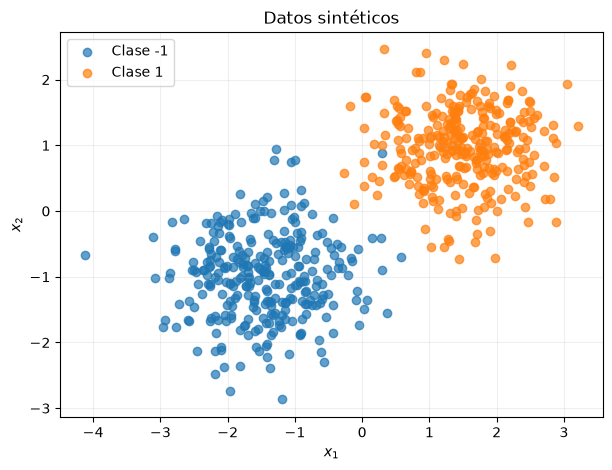

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

for etiqueta in (-1, 1):
    grupo = datos[datos["y"] == etiqueta]  #filtramos solo las filas de esa clase
    ax.scatter(
        grupo["x1"],
        grupo["x2"],
        alpha=0.7,
        label=f"Clase {etiqueta}",
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Datos sintéticos")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

### Lectura previa

1. ¿parece razonable una frontera lineal?;
2. ¿hay solapamiento?;
3. ¿esta gráfica demuestra separabilidad lineal?;
4. ¿por qué sigue siendo útil observarla?

**Respuesta:**

> 1. Sí, parece razonable. Las dos nubes están centradas en puntos bastante alejados entre sí, así que a simple vista una recta debería poder separar la mayoría de los puntos de cada clase.
> 2. Sí hay algo de solapamiento, más que en los datos del perceptrón. Aquí la desviación estándar es más grande, entonces en los bordes de las dos nubes se meten un poco uno en el territorio del otro. Van a quedar algunos puntos cerca de la frontera, o incluso del lado "equivocado".
> 3. Que se vean separadas en el gráfico es una impresión visual, no una prueba. Podríamos estar viendo mal la escala, o el solapamiento podría ser peor de lo que parece a simple vista. Demostrar separabilidad lineal de verdad significaría encontrar explícitamente los pesos que separan las clases sin error, no solo verlo en el gráfico.
> 4. Porque da una intuición rápida de qué esperar antes de entrenar. Si vieramos las nubes completamente revueltas ya se sabría de entrada que ADALINE no va a poder separar bien esto, sin importar cuánto entrene. Como acá sí se ven medio separadas (aunque con solapamiento), es razonable esperar una exactitud alta pero probablemente no perfecta, lo cual sirve luego para comparar contra lo que realmente obtenga el modelo.

# 5. Train, validation y test

Los pesos deben aprenderse únicamente a partir de `train`.

In [ ]:
(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
) = particion_estratificada(X, y)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# 6. Una pieza ya implementada: actualización de pesos

La siguiente función se entrega resuelta.

Con:

\[
\mathbf a=\tilde X\mathbf w,
\qquad
\mathbf e=\mathbf y-\mathbf a,
\]

implementa:

\[
\boxed{
\mathbf w_{\text{nuevo}}
=
\mathbf w+
\frac{\eta}{n}
\tilde X^\top\mathbf e
}
\]

Es una actualización **batch**: usa todo el conjunto recibido para producir una actualización global.

Estudie la función. **No la modifique.**

In [ ]:
def actualizar_pesos_adaline(
    X_aug: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    eta: float,
) -> np.ndarray:
    """Actualiza los pesos de ADALINE mediante batch gradient descent.

    Args:
        X_aug: Matriz de características con x0 = 1.
        y: Vector de etiquetas en {-1, +1}.
        w: Vector actual de pesos.
        eta: Tasa de aprendizaje estrictamente positiva.

    Returns:
        Vector de pesos actualizado.

    Raises:
        ValueError: Si las dimensiones son incompatibles, aparecen
            valores no finitos o eta no es positiva.
    """
    if X_aug.ndim != 2:
        raise ValueError("X_aug debe ser una matriz bidimensional.")
    if y.ndim != 1:
        raise ValueError("y debe ser un vector unidimensional.")
    if w.ndim != 1:
        raise ValueError("w debe ser un vector unidimensional.")
    if X_aug.shape[0] != y.shape[0]:
        raise ValueError("X_aug e y deben tener el mismo número de observaciones.")
    if X_aug.shape[1] != w.shape[0]:
        raise ValueError("El número de columnas de X_aug debe coincidir con len(w).")
    if not np.isfinite(X_aug).all():
        raise ValueError("X_aug contiene valores no finitos.")
    if not np.isfinite(y).all():
        raise ValueError("y contiene valores no finitos.")
    if not np.isfinite(w).all():
        raise ValueError("w contiene valores no finitos.")
    if eta <= 0:
        raise ValueError("eta debe ser estrictamente positiva.")

    salida = X_aug @ w
    error = y - salida
    w_nuevo = w + eta * (X_aug.T @ error) / len(y)

    return w_nuevo

## 6.1 Compruebe una actualización a mano

Considere:

\[
\tilde X=
\begin{bmatrix}
1&0&0\\
1&1&1
\end{bmatrix},
\quad
\mathbf y=
\begin{bmatrix}
-1\\
1
\end{bmatrix},
\quad
\mathbf w=
\begin{bmatrix}
0\\0\\0
\end{bmatrix},
\quad
\eta=0.1.
\]

Calcule manualmente:

1. \(\tilde X\mathbf w\);
2. \(\mathbf e\);
3. \(\tilde X^\top\mathbf e\);
4. \(\mathbf w_{\text{nuevo}}\).

**Resultado esperado por usted:**

\[
\mathbf w_{\text{nuevo}}
=
\boxed{\qquad\qquad\qquad}
\]

In [ ]:
# COMPROBACIÓN — NO MODIFICAR

X_manual = np.array(
    [
        [1.0, 0.0, 0.0],
        [1.0, 1.0, 1.0],
    ]
)
y_manual = np.array([-1.0, 1.0])
w_manual = np.zeros(3)

w_actualizado = actualizar_pesos_adaline(
    X_manual,
    y_manual,
    w_manual,
    eta=0.1,
)

print("Pesos obtenidos:", w_actualizado)
assert np.allclose(w_actualizado, np.array([0.0, 0.05, 0.05]))
print("✓ La función proporcionada reproduce el cálculo esperado.")

# 7. Diseñe antes de programar

## No empiece por el código

La función anterior resuelve una operación, no el algoritmo completo.

Piense en necesidades como:

- validar datos e hiperparámetros;
- incorporar \(x_0=1\);
- inicializar pesos;
- calcular salida lineal;
- calcular pérdida;
- coordinar épocas;
- guardar historial;
- convertir salida lineal en una clase;
- predecir sobre nuevas observaciones.

**No significa que cada elemento deba convertirse en una función.** La descomposición es parte del ejercicio.

Complete esta tabla:

| Función propuesta | Responsabilidad | Entradas | Salida | Dependencias |
|---|---|---|---|---|
| | | | | |
| | | | | |
| | | | | |
| | | | | |
| | | | | |
| | | | | |

### Diagrama

Reemplace las cajas por su propuesta:

```text
datos
  │
  ▼
[                     ]
  │
  ▼
[                     ]
  │
  ▼
[                     ]
  │
  ├──────────────► historial
  │
  ▼
pesos entrenados
```

### Justificación

¿Por qué separó las responsabilidades de esa manera?

> ...

# 8. Pseudocódigo del comportamiento esperado

Este pseudocódigo **no define nombres de funciones**.

```text
RECIBIR X, y, eta y número de épocas

VALIDAR las entradas

INCORPORAR x0 = 1

INICIALIZAR los pesos

PARA cada época:

    ACTUALIZAR los pesos mediante actualizar_pesos_adaline(...)

    CALCULAR la salida lineal con los pesos ya actualizados

    CALCULAR la pérdida de la época

    GUARDAR:
        - número de época
        - pérdida
        - copia de los pesos

DEVOLVER pesos finales e historial
```

Para inferencia:

```text
RECIBIR X y pesos entrenados

INCORPORAR x0 = 1

CALCULAR salida lineal

SI salida > 0:
    clase = +1
EN OTRO CASO:
    clase = -1

DEVOLVER predicciones
```

La función signo **no interviene en la pérdida usada para entrenar ADALINE**.

<details>
<summary><strong>Pista 3 — historial</strong></summary>

Cada época debe permitir recuperar:

- número de época;
- pérdida;
- una copia de los pesos.

</details>

<details>
<summary><strong>Pista 4 — si la pérdida aumenta</strong></summary>

Revise el signo de la actualización, el valor de \(\eta\), que la pérdida use la salida lineal y la escala de las características.

</details>

<details>
<summary><strong>Pista 5 — sesgo</strong></summary>

Mantenga la convención:

\[
x_0=1,
\qquad
w_0 \text{ actúa como sesgo}.
\]

No introduzca un `b` separado.

</details>

# 9. Implemente su arquitectura

Utilice las siguientes celdas para sus funciones auxiliares.

Se espera:

- `type hints`;
- docstrings;
- `raise ValueError` cuando corresponda;
- responsabilidades claras.

Puede añadir más celdas.

In [ ]:
# CELDA DE IMPLEMENTACIÓN 1
# Escriba aquí una o varias funciones auxiliares de SU arquitectura.

In [ ]:
# CELDA DE IMPLEMENTACIÓN 2
# Continúe aquí si necesita más funciones.

In [ ]:
# CELDA DE IMPLEMENTACIÓN 3
# Puede añadir más celdas si su arquitectura lo requiere.

# 10. Interfaces de integración

Su arquitectura interna es libre, pero las celdas posteriores necesitan dos puntos de entrada comunes.

## 10.1 `entrenar_adaline`

El historial debe tener exactamente:

```python
{
    "epoca": ...,
    "perdida": ...,
    "w": ...,
}
```

La pérdida registrada debe corresponder a los pesos **después de la actualización de esa época**.

No se requiere `early stopping`: ejecute exactamente `max_epocas` épocas.

In [ ]:
def entrenar_adaline(
    X: np.ndarray,
    y: np.ndarray,
    eta: float = 0.05,
    max_epocas: int = 100,
) -> tuple[np.ndarray, list[dict[str, object]]]:
    """Entrena ADALINE mediante batch gradient descent.

    Args:
        X: Matriz de características originales.
        y: Vector de etiquetas en {-1, +1}.
        eta: Tasa de aprendizaje estrictamente positiva.
        max_epocas: Número de épocas.

    Returns:
        Tupla (w, historial). Cada registro contiene
        'epoca', 'perdida' y 'w'.

    Raises:
        ValueError: Si los datos o hiperparámetros incumplen el contrato.
    """
    # CELDA A COMPLETAR
    # Coordine aquí las funciones de SU arquitectura.

    w = None
    historial = None
    return w, historial

## 10.2 `predecir_adaline`

Durante inferencia:

\[
\hat y=
\begin{cases}
+1,&z>0,\\
-1,&z\le0.
\end{cases}
\]

In [ ]:
def predecir_adaline(
    X: np.ndarray,
    w: np.ndarray,
) -> np.ndarray:
    """Obtiene predicciones binarias con un ADALINE entrenado.

    Args:
        X: Matriz de características originales.
        w: Vector de pesos entrenado.

    Returns:
        Vector de predicciones en {-1, +1}.
    """
    # CELDA A COMPLETAR
    # Conecte aquí las funciones de SU arquitectura.

    predicciones = None
    return predicciones

# 11. Diseñe sus propias pruebas

En el perceptrón las pruebas fueron proporcionadas. Aquí debe proponerlas usted.

Incluya **al menos cuatro pruebas** relevantes.

Algunas preguntas que pueden inspirarlas:

- ¿se rechazan dimensiones incompatibles?;
- ¿se rechaza \(\eta\le0\)?;
- ¿la pérdida es cero cuando la salida coincide exactamente con \(y\)?;
- ¿la representación con sesgo tiene la forma esperada?;
- ¿las predicciones pertenecen a \(\{-1,+1\}\)?;
- ¿el historial tiene una entrada por época?;
- ¿los pesos almacenados en distintas épocas son copias independientes?

No tiene que utilizar estas mismas pruebas.

In [ ]:
# PRUEBAS DEL ESTUDIANTE
# Escriba al menos cuatro pruebas ejecutables.

# 12. Utilidades para analizar resultados

Estas funciones se entregan implementadas y no pertenecen al núcleo de ADALINE.

In [ ]:
def exactitud(
    y_real: np.ndarray,
    y_pred: np.ndarray,
) -> float:
    if y_real.shape != y_pred.shape:
        raise ValueError("y_real e y_pred deben tener la misma forma.")
    return float(np.mean(y_real == y_pred))


def historial_a_dataframe(
    historial: list[dict[str, object]],
) -> pd.DataFrame:
    filas = []

    for registro in historial:
        fila = {
            "epoca": registro["epoca"],
            "perdida": registro["perdida"],
        }

        for j, valor in enumerate(registro["w"]):
            fila[f"w{j}"] = valor

        filas.append(fila)

    return pd.DataFrame(filas)


def graficar_perdida(
    historial: list[dict[str, object]],
    titulo: str = "Pérdida por época",
) -> None:
    tabla = historial_a_dataframe(historial)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(tabla["epoca"], tabla["perdida"])
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida")
    ax.set_title(titulo)
    ax.grid(alpha=0.2)
    plt.show()


def graficar_frontera(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    titulo: str,
) -> None:
    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError("La gráfica requiere exactamente dos características.")

    fig, ax = plt.subplots(figsize=(7, 5))

    for etiqueta in (-1, 1):
        mascara = y == etiqueta
        ax.scatter(
            X[mascara, 0],
            X[mascara, 1],
            alpha=0.7,
            label=f"Clase {etiqueta}",
        )

    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    if np.isclose(w[2], 0.0):
        if not np.isclose(w[1], 0.0):
            ax.axvline(-w[0] / w[1], linestyle="--", label="Frontera")
    else:
        xs = np.linspace(x_min, x_max, 200)
        ys = -(w[0] + w[1] * xs) / w[2]
        ax.plot(xs, ys, linestyle="--", label="Frontera")

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()

# 13. Primera prueba de integración

No modifique esta celda para hacerla pasar. Si falla, diagnostique si el problema está en contratos, arquitectura, matemática o integración.

In [ ]:
# PRUEBA DE INTEGRACIÓN — NO MODIFICAR

w_base, historial_base = entrenar_adaline(
    X_train,
    y_train,
    eta=0.05,
    max_epocas=100,
)

assert isinstance(w_base, np.ndarray)
assert w_base.shape == (X_train.shape[1] + 1,)
assert np.isfinite(w_base).all()

assert isinstance(historial_base, list)
assert len(historial_base) == 100

for registro in historial_base:
    assert set(registro.keys()) == {"epoca", "perdida", "w"}
    assert np.isfinite(registro["perdida"])
    assert registro["perdida"] >= 0
    assert isinstance(registro["w"], np.ndarray)

pred_train_base = predecir_adaline(X_train, w_base)

assert isinstance(pred_train_base, np.ndarray)
assert pred_train_base.shape == y_train.shape
assert set(np.unique(pred_train_base)).issubset({-1, 1})

print("✓ Las interfaces públicas superan la prueba estructural.")

# 14. ¿Qué hace el learning rate?

Entrene con:

\[
\eta\in\{0.001,\;0.01,\;0.05\}.
\]

Compare pérdida inicial, velocidad de descenso, pérdida final y estabilidad.

In [ ]:
etas = [0.001, 0.01, 0.05]
resultados_eta = {}

for eta in etas:
    w_eta, hist_eta = entrenar_adaline(
        X_train,
        y_train,
        eta=eta,
        max_epocas=100,
    )
    resultados_eta[eta] = {
        "w": w_eta,
        "historial": hist_eta,
    }

fig, ax = plt.subplots(figsize=(8, 5))

for eta, resultado in resultados_eta.items():
    tabla_eta = historial_a_dataframe(resultado["historial"])
    ax.plot(
        tabla_eta["epoca"],
        tabla_eta["perdida"],
        label=f"eta={eta}",
    )

ax.set_xlabel("Época")
ax.set_ylabel("Pérdida")
ax.set_title("Efecto del learning rate")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

### Analice

1. ¿qué valor produce el descenso más lento?;
2. ¿cuál alcanza una pérdida baja más rápidamente?;
3. ¿observa inestabilidad?;
4. ¿qué papel cumple \(\eta\)?

**Respuesta:**

> ...

# 15. Evaluación sobre train, validation y test

Utilice inicialmente:

\[
\eta=0.05.
\]

In [ ]:
w_final, historial_final = entrenar_adaline(
    X_train,
    y_train,
    eta=0.05,
    max_epocas=100,
)

pred_train = predecir_adaline(X_train, w_final)
pred_val = predecir_adaline(X_val, w_final)
pred_test = predecir_adaline(X_test, w_final)

print(f"Exactitud train:      {exactitud(y_train, pred_train):.3f}")
print(f"Exactitud validation: {exactitud(y_val, pred_val):.3f}")
print(f"Exactitud test:       {exactitud(y_test, pred_test):.3f}")

graficar_perdida(
    historial_final,
    "ADALINE — evolución de la pérdida",
)

graficar_frontera(
    X,
    y,
    w_final,
    "ADALINE — frontera de decisión",
)

### Interprete

1. ¿la pérdida parece converger?;
2. ¿train, validation y test son comparables?;
3. ¿qué relación observa entre pérdida cuadrática y exactitud?;
4. ¿por qué la pérdida puede ser positiva aun con muchas clasificaciones correctas?

**Respuesta:**

> ...

# 16. ¿Qué ocurre si las características tienen escalas muy distintas?

Construiremos el mismo problema, pero reemplazaremos:

\[
x_2^\ast=10x_2.
\]

La información de clasificación no cambia, pero la geometría numérica sí.

In [ ]:
X_escala = X.copy()
X_escala[:, 1] = 10.0 * X_escala[:, 1]

(
    X_train_e,
    y_train_e,
    X_val_e,
    y_val_e,
    X_test_e,
    y_test_e,
) = particion_estratificada(
    X_escala,
    y,
    semilla=2026,
)

print("Desviaciones de train:")
print(X_train_e.std(axis=0))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for etiqueta in (-1, 1):
    mascara = y_train_e == etiqueta
    ax.scatter(
        X_train_e[mascara, 0],
        X_train_e[mascara, 1],
        alpha=0.7,
        label=f"Clase {etiqueta}",
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$10x_2$")
ax.set_title("Mismo problema, distinta escala")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 16.1 Entrene sin estandarizar

Use:

\[
\eta=0.05.
\]

Si la pérdida se comporta mal, no cambie de inmediato el algoritmo. Observe primero.

In [ ]:
w_escala, hist_escala = entrenar_adaline(
    X_train_e,
    y_train_e,
    eta=0.05,
    max_epocas=50,
)

tabla_escala = historial_a_dataframe(hist_escala)

print("Primeras pérdidas:")
display(tabla_escala[["epoca", "perdida"]].head())

print("Últimas pérdidas:")
display(tabla_escala[["epoca", "perdida"]].tail())

graficar_perdida(
    hist_escala,
    "ADALINE sin estandarizar — eta=0.05",
)

### Observe

Si la pérdida aumenta u oscila:

> ¿qué cambió respecto al experimento anterior si las etiquetas y el problema conceptual son los mismos?

**Respuesta:**

> ...

# 17. Estandarización

Usaremos únicamente estadísticas de train:

\[
x_j^{\mathrm{std}}
=
\frac{x_j-\mu_j^{(\mathrm{train})}}
{\sigma_j^{(\mathrm{train})}}.
\]

Validation y test se transforman con esos mismos parámetros.

In [ ]:
(
    X_train_std,
    X_val_std,
    X_test_std,
    media_train,
    desviacion_train,
) = estandarizar_desde_train(
    X_train_e,
    X_val_e,
    X_test_e,
)

print("Media de train estandarizado:")
print(X_train_std.mean(axis=0))

print("\nDesviación de train estandarizado:")
print(X_train_std.std(axis=0))

In [ ]:
w_std, hist_std = entrenar_adaline(
    X_train_std,
    y_train_e,
    eta=0.05,
    max_epocas=50,
)

graficar_perdida(
    hist_std,
    "ADALINE estandarizado — eta=0.05",
)

pred_train_std = predecir_adaline(X_train_std, w_std)
pred_val_std = predecir_adaline(X_val_std, w_std)
pred_test_std = predecir_adaline(X_test_std, w_std)

print(f"Exactitud train:      {exactitud(y_train_e, pred_train_std):.3f}")
print(f"Exactitud validation: {exactitud(y_val_e, pred_val_std):.3f}")
print(f"Exactitud test:       {exactitud(y_test_e, pred_test_std):.3f}")

### Compare

1. ¿qué ocurrió sin estandarizar?;
2. ¿qué cambió después?;
3. ¿por qué la escala afecta gradient descent?;
4. ¿qué relación encuentra entre escala, gradiente y learning rate?

**Respuesta:**

> ...

# 18. Una mirada computacional

Si:

\[
\tilde X\in\mathbb R^{n\times(d+1)},
\]

la actualización contiene:

\[
\tilde X\mathbf w
\quad\text{y}\quad
\tilde X^\top\mathbf e.
\]

Responda:

1. ¿cuál es el costo dominante de una época?;
2. ¿cuál es el costo de \(E\) épocas?;
3. ¿qué costo adicional tiene almacenar una copia de \(\mathbf w\) por época?

**Respuesta:**

> ...

# 19. Perceptrón vs. ADALINE

Complete:

| Aspecto | Perceptrón | ADALINE |
|---|---|---|
| Entrada neta | | |
| Etiquetas | | |
| Salida usada durante aprendizaje | | |
| Criterio de cambio de pesos | | |
| Función de pérdida explícita | | |
| ¿Usa gradiente? | | |
| Actualizaciones por época en la versión estudiada | | |
| Papel de `sign` | | |
| Sensibilidad a escala | | |

Después responda:

> **¿Por qué ADALINE constituye un puente conceptual entre el perceptrón y las redes neuronales entrenadas mediante gradient descent?**

**Respuesta:**

> ...

# 20. Vuelva a mirar su arquitectura

1. ¿tuvo que modificar su diseño inicial?;
2. ¿qué función terminó teniendo la responsabilidad más compleja?;
3. ¿hay una función con demasiadas responsabilidades?;
4. ¿qué refactorización haría si el proyecto creciera?;
5. ¿dónde ubicó las validaciones y por qué?;
6. ¿qué pieza podría reutilizar en otro modelo entrenado con gradient descent?

**Respuesta:**

> ...

# 21. Calidad y entrega

Antes de entregar:

1. reinicie el kernel;
2. ejecute **Run All**;
3. compruebe que no existen errores;
4. verifique que su arquitectura coincide con su implementación;
5. ejecute sus pruebas;
6. interprete las curvas de pérdida;
7. confirme que no modificó `actualizar_pesos_adaline`;
8. no suba el ambiente virtual.

En terminal:

```bash
ruff check .
```

y:

```bash
git status
```

Después:

```bash
git add .
git commit -m "Implementa ADALINE con arquitectura funcional"
git pull
git push
```

## Criterio de finalización

El ejercicio está completo cuando puede defender:

\[
\boxed{
\text{formulación matemática}
\rightarrow
\text{arquitectura}
\rightarrow
\text{implementación}
\rightarrow
\text{pruebas}
\rightarrow
\text{optimización}
\rightarrow
\text{evaluación}
}
\]